In [1]:
!pip install kagglehub==1.0.0

### Files Setup

In [24]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [25]:
try:
    path = Path('/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies')

    if not path.exists():
        raise FileNotFoundError(f"The specified path does not exist: {path}")

except FileNotFoundError:
    path = Path('/content/drive/MyDrive/AdvancedMachineLearning2/aca-butterflies')

if not path.exists():
    raise FileNotFoundError(f"The specified path does not exist: {path}")

print(f"Using path: {path}")

Using path: /content/drive/MyDrive/AdvancedMachineLearning2/aca-butterflies


### Load data

In [26]:
# Load the dataset on Colab machine
!cp "/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies.zip" "/content/butterflies.zip"

cp: cannot stat '/content/drive/MyDrive/Universidade/Mestrado/2 Semestre/Aprendizagem Computacional Avançada/AML_Butterfly/aca-butterflies.zip': No such file or directory


In [27]:
!cp "/content/drive/MyDrive/AdvancedMachineLearning2/aca-butterflies.zip" "/content/butterflies.zip"

In [28]:
!unzip -q /content/butterflies.zip -d /content/dataset_local

In [29]:
import os
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms

import warnings
warnings.filterwarnings("ignore")

In [30]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [31]:
BATCH_SIZE = 32
IMAGE_SIZE = 64

In [32]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [33]:
# load the data
img_dir = Path("/content/dataset_local/train")
# img_dir = os.path.join(path, 'train')
df = pd.read_csv(os.path.join(path, 'train.csv'))

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

# encapsulate data into dataloader form
dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)
print(f"Dataset size: {len(dataset)} samples")
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Dataset size: 5199 samples


In [34]:
print(f"Number of samples: {len(dataset)}")
print(f"Number of classes: {len(dataset.classes)}")

Number of samples: 5199
Number of classes: 75


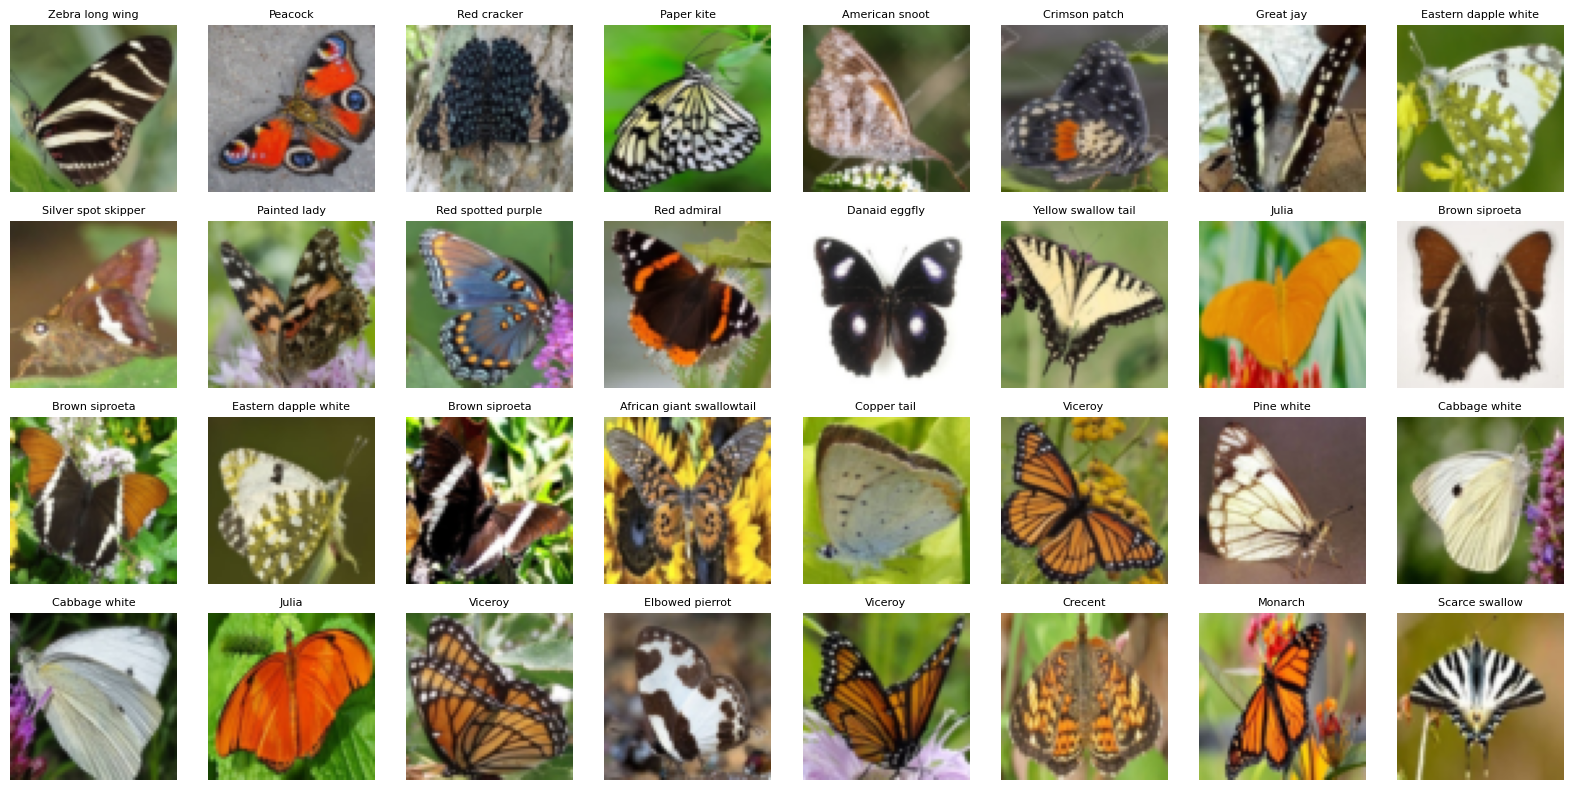

In [35]:
# Get a batch of images from the dataloader
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i, img in enumerate(images):
    img = img.permute(1, 2, 0).numpy()
    label_idx = labels[i].item()
    label_name = dataset.classes[label_idx]
    axes[i].imshow(img)
    axes[i].set_title(label_name.capitalize(), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Preparation
In this section we divide the dataset into train, validation and test.

In [36]:
from sklearn.model_selection import train_test_split

# 1.First we split the data into training/validation (85%) and test (15%)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df['label']
)

# 2. Then, we split the remaining data between training and validation
# 0.176 aprox represents 15% of the original total (0.15 / 0.85)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.176,
    random_state=42,
    stratify=train_val_df['label']
)

print(f"Training: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

#* DataLoaders
# Training
train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Validation
val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Test
test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Training: 3641 | Validation: 778 | Test: 780


# Classifier

In [37]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes):

        """
        Baseline Convolutional Neural Network for Butterfly Classification.
        
        Args:
            num_classes (int): Number of target species/classes (75 for this dataset).
        """

        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                # Layer 1: Convolutional feature extraction preserving spatial dimensions
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                
                # Layer 2: Second convolution to build deeper feature representations
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                # Downsamples spatial dimensions by 2x (Height and Width halved)
                nn.MaxPool2d(2, 2)
            )

        # Feature Extractor: Progressively extracts high-level semantic abstractions
        self.features = nn.Sequential(
            conv_block(3, 64), # Input: 3 channels (RGB) -> Output: 64 channels
            conv_block(64, 128), # Input: 64 channels      -> Output: 128 channels
            conv_block(128, 256), # Input: 128 channels     -> Output: 256 channels
            # Global pooling forces spatial dimensions to 1x1, minimizing dense layer parameters
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Fully Connected Classifier: Maps extracted features to final class logits
        self.classifier = nn.Sequential(
            *[layer for size in [256, 512, 1024]
            for layer in (nn.Linear(size, size*2), nn.ReLU(inplace=True), nn.Dropout(p=0.5))],
            # Final output layer: Maps 2048 hidden units to the 75 butterfly classes
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

### Training Loop

In [42]:
import copy
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=25, patience=5, scheduler=None):
    model = model.to(device)
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    # Early Stopping variables
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(num_epochs):
        print(f'[{epoch+1}/{num_epochs}]', end=' ')
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode (enables Dropout, BatchNorm, etc.)
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluation mode (disables Dropout, etc.)
                dataloader = val_loader
                
            running_loss = 0.0
            running_corrects = 0
            total_samples = 0
            
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward e and optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                # Stats
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels).item()
                total_samples += inputs.size(0)
                
            epoch_loss = running_loss / total_samples
            epoch_acc = running_corrects / total_samples
            
            print(f'{phase.capitalize()}: Loss = {epoch_loss:.4f} Accuracy = {epoch_acc*100:.2f}% |', end=' ')
            
            # Save history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                
                # Update Scheduler if exists (based on Validation Loss)
                if scheduler is not None:
                    scheduler.step(epoch_loss)
                
                # Early Stopping logic
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
        
        # Early Stopping check after each epoch
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}! Validation loss did not improve for {patience} epochs.')
            break
            
        print()
        
    print(f'\nBest Validation Loss: {best_val_loss:.4f}')
    
    model.load_state_dict(best_model_wts)
    return history

In [43]:
n_classes = len(train_dataset.classes)
print(f"Number of classes: {n_classes}")
model = BaselineCNN(num_classes=n_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs = 30  
patience = 5   

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        
history = train_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    device=device,
    num_epochs=num_epochs,          # Max epochs for training
    patience=patience,              # Early stopping patience (number of epochs with no improvement after which training will be stopped)
    scheduler=scheduler
)

Number of classes: 75
[1/30] Train: Loss = 4.2490 Accuracy = 2.58% | Val: Loss = 4.0931 Accuracy = 3.08% | 
[2/30] Train: Loss = 3.9049 Accuracy = 4.39% | Val: Loss = 3.6848 Accuracy = 6.43% | 
[3/30] Train: Loss = 3.7001 Accuracy = 5.60% | Val: Loss = 3.4586 Accuracy = 9.64% | 
[4/30] Train: Loss = 3.5224 Accuracy = 7.85% | Val: Loss = 3.5868 Accuracy = 9.13% | 
[5/30] Train: Loss = 3.3590 Accuracy = 10.16% | Val: Loss = 3.1773 Accuracy = 14.27% | 
[6/30] Train: Loss = 3.2435 Accuracy = 10.82% | Val: Loss = 3.2426 Accuracy = 13.24% | 
[7/30] Train: Loss = 3.1658 Accuracy = 13.40% | Val: Loss = 2.9914 Accuracy = 16.07% | 
[8/30] Train: Loss = 3.0802 Accuracy = 14.61% | Val: Loss = 3.2064 Accuracy = 14.14% | 
[9/30] Train: Loss = 2.9819 Accuracy = 16.31% | Val: Loss = 2.9509 Accuracy = 16.07% | 
[10/30] Train: Loss = 2.9237 Accuracy = 17.14% | Val: Loss = 2.8909 Accuracy = 19.28% | 
[11/30] Train: Loss = 2.8679 Accuracy = 19.50% | Val: Loss = 2.7168 Accuracy = 25.32% | 
[12/30] Train: L

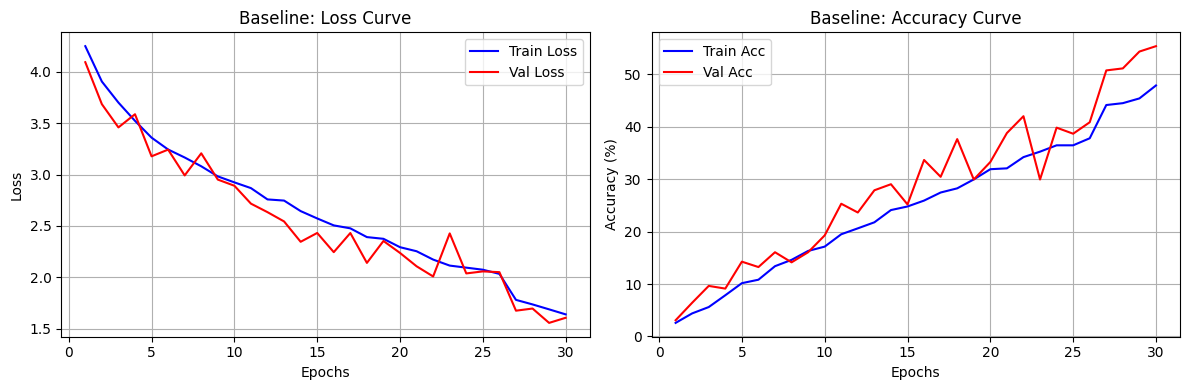

🎯 Il punto di partenza è stabilito! Accuratezza massima della Baseline sulla Validazione: 55.40%


In [44]:
import matplotlib.pyplot as plt

# Estraiamo i dati salvati nella variabile history
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 4))

# Subplot per la Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='red')
plt.title('Baseline: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot per l'Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in history['train_acc']], label='Train Acc', color='blue')
plt.plot(epochs_range, [acc * 100 for acc in history['val_acc']], label='Val Acc', color='red')
plt.title('Baseline: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Stampiamo il verdetto finale
best_acc = max(history['val_acc']) * 100
print(f"🎯 Il punto di partenza è stabilito! Accuratezza massima della Baseline sulla Validazione: {best_acc:.2f}%")

### Evaluation on Test

In [48]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_on_test(model, test_loader, device, class_names=None):
    """
    Evaluates the final model on the Test Set and prints the classification report and confusion matrix.
    Args:
        model: the trained model to evaluate
        test_loader: DataLoader for the test set
        device: 'cuda' or 'cpu'
        class_names: list of class names corresponding to the labels (optional, for better report readability)
    """
    model.to(device)
    model.eval()

    test_corrects = 0
    test_total = 0

    all_preds = []
    all_labels = []

    print("Evaluating the final model on the Test Set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            test_corrects += torch.sum(predicted == labels).item()
            test_total += labels.size(0)

            # Save predictions and labels for the report and confusion matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    
    test_accuracy = test_corrects / test_total
    print(f"Test Accuracy: {test_accuracy*100:.2f}%")
    print("\n" + "="*15)
    print("FINAL RESULTS (TEST SET)")
    print("="*15 + "\n")


    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # Generate and Plot the Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title('Confusion Matrix', fontsize=16)
    plt.ylabel('True Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)


    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds

Evaluating the final model on the Test Set...
Test Accuracy: 55.90%

FINAL RESULTS (TEST SET)

                           precision    recall  f1-score   support

                   ADONIS       1.00      0.82      0.90        11
AFRICAN GIANT SWALLOWTAIL       0.80      0.44      0.57         9
           AMERICAN SNOOT       0.50      0.33      0.40         9
                    AN 88       1.00      0.90      0.95        10
                  APPOLLO       0.58      1.00      0.73        11
                    ATALA       0.67      0.67      0.67        12
 BANDED ORANGE HELICONIAN       0.55      0.50      0.52        12
           BANDED PEACOCK       0.69      0.90      0.78        10
            BECKERS WHITE       0.25      0.30      0.27        10
         BLACK HAIRSTREAK       0.47      0.80      0.59        10
              BLUE MORPHO       0.75      0.67      0.71         9
        BLUE SPOTTED CROW       0.09      0.10      0.10        10
           BROWN SIPROETA       0

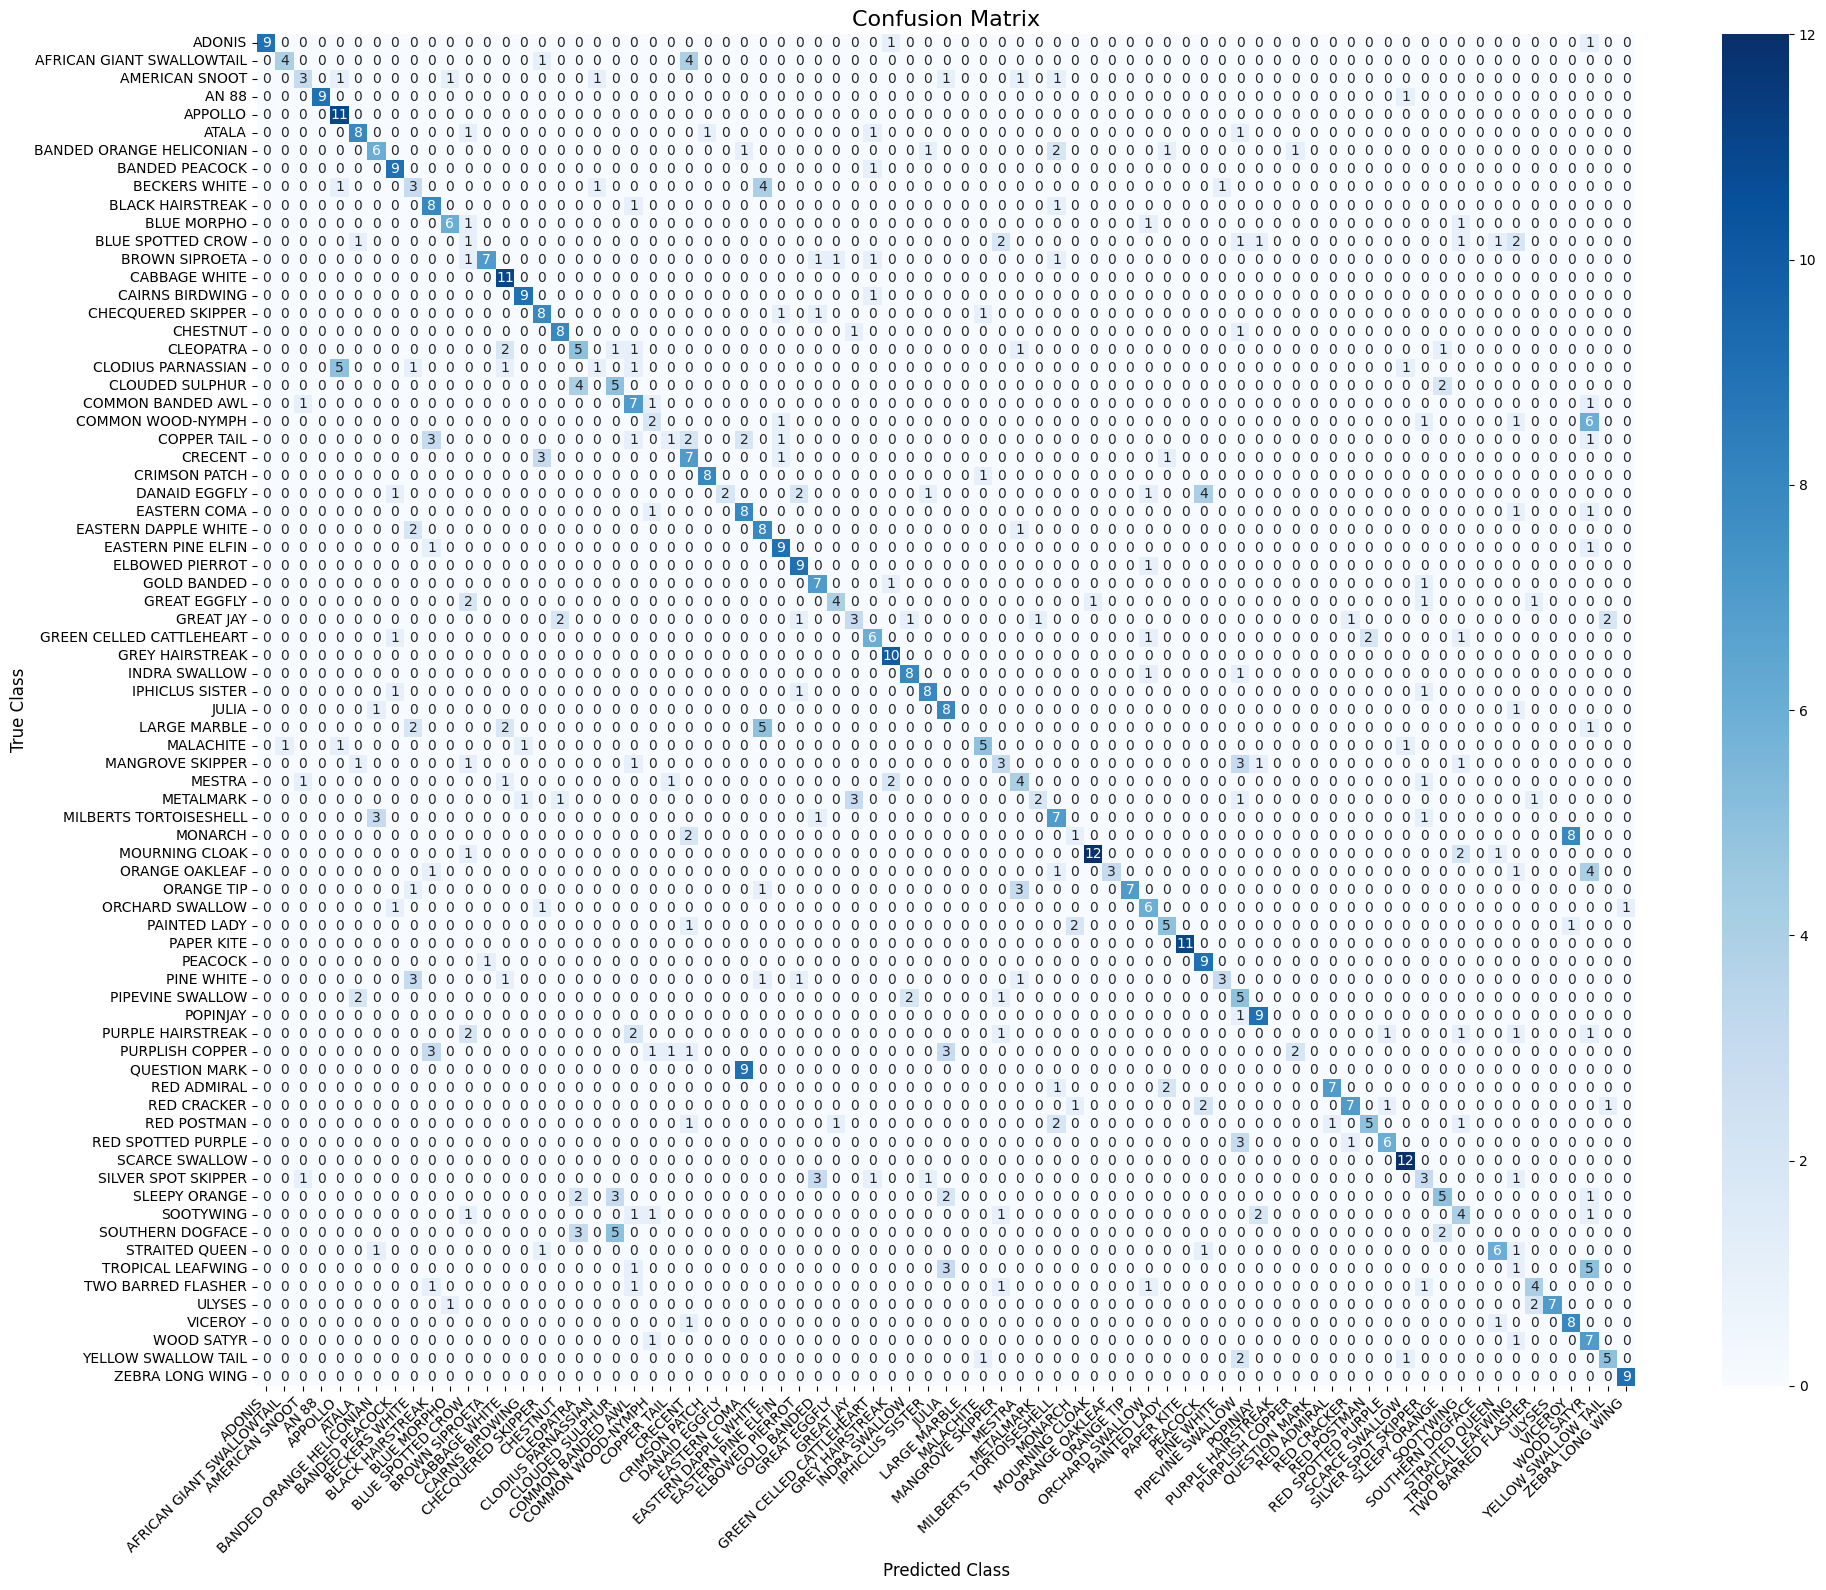

In [49]:
# Evaluate the final model on the Test Set
labels_reais, labels_previstos = evaluate_on_test(
    model,
    test_loader,
    device,
    class_names=test_dataset.classes
)

## Generative Models
We are going to implement:
- Variational Autoencoder (VAE)
- Conditional VAE (cVAE)
- Generative Adversarial Network (GAN)
- Conditional GAN (cGAN)
- Diffusion Model

#### Butterfly Conditional VAE
We can insert a grid search???

In [50]:
import torch
import torch.nn as nn

class ButterflyConditionalVAE(nn.Module):
    def __init__(self, num_classes, latent_dim=128, embedded_size=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.embedded_size = embedded_size

        # Livelli di embedding per le classi (condizione)
        self.encoder_embedding = nn.Embedding(num_classes, embedded_size)
        self.decoder_embedding = nn.Embedding(num_classes, embedded_size)

        # 1 canale aggiuntivo per la condizione (classe) concatenato all'input dell'encoder
        self.enc_label_layer = nn.Linear(embedded_size, 64 * 64)  # Mappa l'embedding della classe a un'immagine di dimensioni 64x64

        # Encoder: Convoluzioni per ridurre lo spazio spaziale (64x64 -> 4x4)
        # riceve 3 canali RGB + 1 canale di condizione (classe) -> totale 4 canali in ingresso
        self.encoder = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=4, stride=2, padding=1),  # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),# -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# -> 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Flatten() # -> 256 * 4 * 4 = 4096
        )

        # Lineari per i parametri dello spazio latente (Media e Log-Varianza)
        self.fc_mu = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)

        # Decoder Input: Riporta il vettore latente a dimensioni utili per le convoluzioni
        self.decoder_input = nn.Linear(latent_dim + embedded_size, 4096)

        # Decoder: Convoluzioni Trasposte per ricostruire l'immagine (4x4 -> 64x64)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # -> 64x64
            nn.Sigmoid() # Mappa l'output tra [0, 1] accordandosi con le normalizzazioni standard
        )

    def reparameterize(self, mu, logvar):
        """Trick di riparametrizzazione per consentire la backpropagation"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, labels):
        # Condizionamento dell'Encoder
        label_emb_enc = self.encoder_embedding(labels)  # Embedding della classe
        label_channel = self.enc_label_layer(label_emb_enc).view(-1, 1, 64, 64)  # Mappa l'embedding a un'immagine di dimensioni 64x64

        x_conditional = torch.cat([x, label_channel], dim=1) # Shape: (batch, 4, 64, 64)
        
        # passaggio encoder
        hidden = self.encoder(x_conditional)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        z = self.reparameterize(mu, logvar)


        # Condizionamento Decoder
        # Concatena il vettore latente z con l'embedding della classe dedicata
        label_emb_dec = self.decoder_embedding(labels)
        z_conditional = torch.cat([z, label_emb_dec], dim=1)  # Shape: (batch, latent_dim + embedded_size)
        
        return self.decoder(self.decoder_input(z_conditional)), mu, logvar

    def sample(self, num_samples, labels, device):
        """Genera nuove farfalle partendo da puro rumore gaussiano e condizionando sulla classe desiderata"""
        z = torch.randn(num_samples, self.latent_dim).to(device)
        label_emb_dec = self.decoder_embedding(labels)
        z_conditional = torch.cat([z, label_emb_dec], dim=1)
        samples = self.decoder(self.decoder_input(z_conditional))
        return samples

In [51]:
def vae_loss_function(recon_x, x, mu, logvar, beta = 1.0):
    
    # Reconstruction Loss: Measures how well the model reconstructs the input image.
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # KL Divergence: Acts as a regularizer, pushing the latent distribution toward N(0, 1)[cite: 74, 83].
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    kl_loss = kl_loss / x.size(0)  # normalized by batch size

    # Total Loss: Combines the two objectives using the 'beta' hyperparameter.
    total_loss = recon_loss + beta * kl_loss  # normalized by batch size
    
    return total_loss, recon_loss, kl_loss

### Training Loop for VAE

In [53]:
def train_vae(model, dataloader, optimizer, beta = 0.7, num_epochs=20):
    
    model = model.to(device)
    history = {
        'total_loss': [],
        'recon_loss': [],
        'kl_loss': []
    }
    
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        train_recon_loss = 0
        train_kl_loss = 0
        for x, labels in dataloader:
            x = x.to(device)
            labels = labels.to(device)

            # The model returns the reconstruction, latent mean (mu), and log-variance
            recon_x, mu, logvar = model(x, labels)

            # LOSS CALCULATION
            # Compute the weighted ELBO (Evidence Lower Bound) loss
            loss, recon_loss, kl_loss = vae_loss_function(recon_x, x, mu, logvar, beta=beta)

            #Backpropagation and update weights
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0) 
            train_recon_loss += recon_loss.item() * x.size(0)
            train_kl_loss += kl_loss.item() * x.size(0)
        
        n = len(dataloader.dataset)
        avg_total = total_loss / n
        avg_recon = train_recon_loss / n
        avg_kl = train_kl_loss / n

        history['total_loss'].append(avg_total)
        history['recon_loss'].append(avg_recon)
        history['kl_loss'].append(avg_kl)

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_total:.4f} (Recon: {avg_recon:.4f}, KL: {avg_kl:.4f})")
    
    return history


In [ ]:
import torchvision.utils as vutils

def plot_generated_butterflies(vae_model, class_to_idx, device, num_examples=8):
    vae_model.eval()
    with torch.no_grad():
        # Scegliamo alcune classi a caso da voler generare
        classes_to_generate = list(class_to_idx.keys())[:num_examples]
        labels_int = [class_to_idx[cls] for cls in classes_to_generate]
        labels_tensor = torch.tensor(labels_int, dtype=torch.long).to(device)
        
        # Generiamo le immagini partendo da puro rumore gaussiano
        samples = vae_model.sample(num_samples=num_examples, labels=labels_tensor, device=device)
        
        # Creiamo una griglia
        grid = vutils.make_grid(samples.cpu(), nrow=4, padding=2, normalize=False)
        
        plt.figure(figsize=(10, 5))
        plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
        plt.axis('off')
        plt.title("Esempi di farfalle generate dalla Conditional VAE")
        plt.show()


In [54]:
def evaluate_vae(model, dataloader, beta=0.7):

    """
    Evaluates the VAE's performance on a the test set.
    """

    model.eval()
    total_loss = 0.0
    recon_loss = 0.0
    kl_loss = 0.0
    mse = 0.0
    mae = 0.0
    n = 0

    # Disable gradient calculations for efficient inference
    with torch.no_grad():
        for x, labels in dataloader:
            x = x.to(device)
            labels = labels.to(device)
            
            # Forward pass: obtain reconstruction and latent parameters
            recon_x, mu, logvar = model(x, labels)

            # PROBABILISTIC LOSS EVALUATION
            # Evaluates how well the model follows the VAE objective
            loss, recon, kl = vae_loss_function(recon_x, x, mu, logvar, beta=beta)

            total_loss += loss.item() * x.size(0)
            recon_loss += recon.item() * x.size(0)
            kl_loss += kl.item() * x.size(0)

            # Calcoliamo MSE e MAE medi per pixel direttamente nel batch attuale
            # reduction='mean' calcola già la media sull'immagine e sui canali
            mse += F.mse_loss(recon_x, x, reduction='mean').item() * x.size(0)
            mae += F.l1_loss(recon_x, x, reduction='mean').item() * x.size(0)


            n += x.size(0)


    return {
        'total_loss': total_loss / n,
        'recon_loss': recon_loss / n,
        'kl_loss': kl_loss / n,
        'pixel_mse': mse / n,
        'pixel_mae': mae / n
    }
    

In [57]:
n_classes = len(train_dataset.classes)
print(f"Number of classes: {n_classes}")

# Inizializziamo il VAE con uno spazio latente di 128 dimensioni
vae = ButterflyConditionalVAE(num_classes=n_classes, latent_dim=128)

vae_optimizer = optim.Adam(vae.parameters(), lr=0.001)

# Lo addestriamo usando le immagini reali del train_loader
vae_history = train_vae(
    model=vae, 
    dataloader=train_loader, 
    optimizer=vae_optimizer, 
    beta=0.001,
    num_epochs=50
)

Number of classes: 75
Epoch 1/50 - Loss: 0.0654 (Recon: 0.0566, KL: 8.8064)
Epoch 2/50 - Loss: 0.0517 (Recon: 0.0455, KL: 6.1778)
Epoch 3/50 - Loss: 0.0487 (Recon: 0.0429, KL: 5.8292)
Epoch 4/50 - Loss: 0.0473 (Recon: 0.0417, KL: 5.5565)
Epoch 5/50 - Loss: 0.0460 (Recon: 0.0406, KL: 5.4276)
Epoch 6/50 - Loss: 0.0447 (Recon: 0.0395, KL: 5.2689)
Epoch 7/50 - Loss: 0.0437 (Recon: 0.0385, KL: 5.2041)
Epoch 8/50 - Loss: 0.0431 (Recon: 0.0380, KL: 5.1329)
Epoch 9/50 - Loss: 0.0428 (Recon: 0.0377, KL: 5.0680)
Epoch 10/50 - Loss: 0.0421 (Recon: 0.0371, KL: 4.9869)
Epoch 11/50 - Loss: 0.0417 (Recon: 0.0365, KL: 5.1623)
Epoch 12/50 - Loss: 0.0414 (Recon: 0.0362, KL: 5.2593)
Epoch 13/50 - Loss: 0.0412 (Recon: 0.0359, KL: 5.2794)
Epoch 14/50 - Loss: 0.0409 (Recon: 0.0356, KL: 5.2984)
Epoch 15/50 - Loss: 0.0407 (Recon: 0.0354, KL: 5.3157)
Epoch 16/50 - Loss: 0.0402 (Recon: 0.0350, KL: 5.2339)
Epoch 17/50 - Loss: 0.0402 (Recon: 0.0348, KL: 5.3629)
Epoch 18/50 - Loss: 0.0402 (Recon: 0.0348, KL: 5.364

Performance della CVAE sul Test Set:
 -> MSE Medio per Pixel: 0.03421
 -> MAE Medio per Pixel: 0.14241


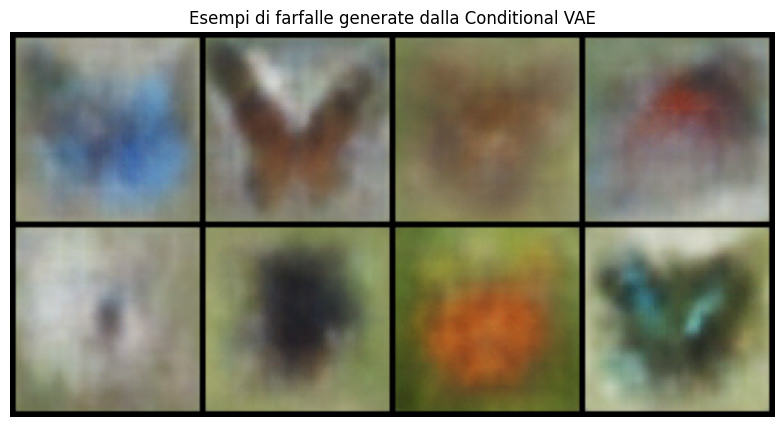

In [58]:
# Cella di Valutazione Quantitativa sul Test Set Locale
vae_test_metrics = evaluate_vae(vae, test_loader, beta=0.001)
print("Performance della CVAE sul Test Set:")
print(f" -> MSE Medio per Pixel: {vae_test_metrics['pixel_mse']:.5f}")
print(f" -> MAE Medio per Pixel: {vae_test_metrics['pixel_mae']:.5f}")

# cella di generazione visiva
plot_generated_butterflies(vae, train_dataset.class_to_idx, device, num_examples=8)

In [60]:
class SyntheticButterflyDataset(data.Dataset):
    """Dataset personalizzato per i dati generati dalla VAE per garantire compatibilità totale"""
    def __init__(self, images, labels):
        # Ci assicuriamo che tutto sia su CPU e con i tipi di dato corretti
        self.images = images.detach().cpu().float()
        self.labels = labels.detach().cpu().long() # Forza torch.long come il dataset reale

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Restituisce esattamente la stessa struttura (immagine, label) del dataset reale
        return self.images[idx], self.labels[idx]


def generate_balanced_synthetic_data(vae_model, train_df, train_dataset, device='cpu'):
    vae_model.eval()
    gen_images = []
    gen_labels = []
    
    # 1. Contiamo la frequenza di ogni classe nel DataFrame originale
    class_counts = train_df['label'].value_counts()
    max_samples = class_counts.max()
    
    class_to_idx = train_dataset.class_to_idx
    print(f"Target di bilanciamento per ogni classe: {max_samples} immagini.")
    print("Generazione mirata in corso...")
    
    with torch.no_grad():
        for class_name, class_idx in class_to_idx.items():
            real_count = class_counts.get(class_name, 0)
            num_to_generate = max_samples - real_count
            
            if num_to_generate > 0:
                # Creiamo il vettore di label (forzando esplicitamente il tipo long)
                labels_tensor = torch.full((num_to_generate,), class_idx, dtype=torch.long, device=device)
                
                # Generiamo i campioni mancanti
                samples = vae_model.sample(num_samples=num_to_generate, labels=labels_tensor, device=device)
                
                # Spostiamo subito su CPU per liberare memoria GPU e prevenire bug di multiprocessing
                gen_images.append(samples.cpu())
                gen_labels.append(labels_tensor.cpu())
                
    if len(gen_images) > 0:
        # Uniamo tutti i tensori generati
        all_gen_images = torch.cat(gen_images, dim=0)
        all_gen_labels = torch.cat(gen_labels, dim=0)
        
        # Usiamo il nostro dataset personalizzato anziché TensorDataset
        return SyntheticButterflyDataset(all_gen_images, all_gen_labels)
    else:
        print("Il dataset è già perfettamente bilanciato!")
        return None

In [61]:
# 1. Generiamo il dataset sintetico bilanciato (ora restituisce un SyntheticButterflyDataset)
synthetic_balanced_dataset = generate_balanced_synthetic_data(
    vae_model=vae, 
    train_df=train_df, 
    train_dataset=train_dataset, 
    device=device
)

# 2. Concateniamo i due dataset
if synthetic_balanced_dataset is not None:
    augmented_dataset = data.ConcatDataset([train_dataset, synthetic_balanced_dataset])
    print(f"\nCampioni reali di Train: {len(train_dataset)}")
    print(f"Campioni sintetici generati per bilanciare: {len(synthetic_balanced_dataset)}")
    print(f"Dimensione totale del nuovo dataset bilanciato: {len(augmented_dataset)}")
else:
    augmented_dataset = train_dataset

# 3. Creiamo il DataLoader Aumentato
# Se riscontri ancora problemi con num_workers, impostalo temporaneamente a 0 per fare il debug
augmented_train_loader = data.DataLoader(
    augmented_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=2, 
    pin_memory=True
)

Target di bilanciamento per ogni classe: 73 immagini.
Generazione mirata in corso...

Campioni reali di Train: 3641
Campioni sintetici generati per bilanciare: 1834
Dimensione totale del nuovo dataset bilanciato: 5475


### Vediamo se le prestazioni della Baseline CNN migliorano o peggiorano con il dataset aumentato

In [62]:
import torch.optim as optim
import torch.nn as nn

# 1. Recuperiamo dinamicamente il numero corretto di classi
n_classes = len(train_dataset.classes)

# 2. Inizializziamo un'istanza NUOVA e PULITA della BaselineCNN
# (Questo garantisce che il modello non riparta da quanto imparato nel primo addestramento)
vae_augmented_model = BaselineCNN(num_classes=n_classes)

# 3. Configura gli stessi identici iperparametri usati per la prima Baseline (Fair Comparison)
optimizer_aug = optim.Adam(vae_augmented_model.parameters(), lr=0.001)
criterion_aug = nn.CrossEntropyLoss()
scheduler_aug = optim.lr_scheduler.ReduceLROnPlateau(optimizer_aug, mode='min', factor=0.5, patience=3)

# Numero di epoche e patience per l'Early Stopping coerenti con il primo esperimento
num_epochs_aug = 30
patience_aug = 5

print("========================================================================")
print("Inizio addestramento della BaselineCNN con DATA AUGMENTATION (CVAE Balanced)")
print(f"Dimensione del Training Set Aumentato: {len(augmented_train_loader.dataset)} immagini")
print(f"Dimensione del Validation Set Reale: {len(val_loader.dataset)} immagini")
print("========================================================================")

# 4. Avviamo l'addestramento riutilizzando la tua funzione train_model
history_augmented = train_model(
    model=vae_augmented_model, 
    train_loader=augmented_train_loader, # <--- Usiamo il loader BILANCIATO (Reali + VAE)
    val_loader=val_loader,               # <--- Manteniamo il validation loader REALE originale
    criterion=criterion_aug, 
    optimizer=optimizer_aug, 
    device=device,
    num_epochs=num_epochs_aug,          
    patience=patience_aug,              
    scheduler=scheduler_aug
)

Inizio addestramento della BaselineCNN con DATA AUGMENTATION (CVAE Balanced)
Dimensione del Training Set Aumentato: 5475 immagini
Dimensione del Validation Set Reale: 778 immagini
[1/30] Train: Loss = 4.0802 Accuracy = 3.16% | Val: Loss = 3.8623 Accuracy = 4.37% | 
[2/30] Train: Loss = 3.7896 Accuracy = 5.26% | Val: Loss = 3.7911 Accuracy = 6.04% | 
[3/30] Train: Loss = 3.6482 Accuracy = 6.54% | Val: Loss = 3.5249 Accuracy = 8.10% | 
[4/30] Train: Loss = 3.5387 Accuracy = 8.31% | Val: Loss = 3.4654 Accuracy = 9.25% | 
[5/30] Train: Loss = 3.4433 Accuracy = 9.59% | Val: Loss = 3.7918 Accuracy = 8.35% | 
[6/30] Train: Loss = 3.3561 Accuracy = 9.92% | Val: Loss = 3.2651 Accuracy = 10.67% | 
[7/30] Train: Loss = 3.2757 Accuracy = 11.32% | Val: Loss = 3.2277 Accuracy = 12.72% | 
[8/30] Train: Loss = 3.2058 Accuracy = 12.18% | Val: Loss = 3.1474 Accuracy = 13.88% | 
[9/30] Train: Loss = 3.1362 Accuracy = 13.57% | Val: Loss = 3.0805 Accuracy = 16.97% | 
[10/30] Train: Loss = 3.0980 Accuracy =

Evaluating the final model on the Test Set...
Test Accuracy: 55.90%

FINAL RESULTS (TEST SET)

                           precision    recall  f1-score   support

                   ADONIS       1.00      0.82      0.90        11
AFRICAN GIANT SWALLOWTAIL       0.80      0.44      0.57         9
           AMERICAN SNOOT       0.50      0.33      0.40         9
                    AN 88       1.00      0.90      0.95        10
                  APPOLLO       0.58      1.00      0.73        11
                    ATALA       0.67      0.67      0.67        12
 BANDED ORANGE HELICONIAN       0.55      0.50      0.52        12
           BANDED PEACOCK       0.69      0.90      0.78        10
            BECKERS WHITE       0.25      0.30      0.27        10
         BLACK HAIRSTREAK       0.47      0.80      0.59        10
              BLUE MORPHO       0.75      0.67      0.71         9
        BLUE SPOTTED CROW       0.09      0.10      0.10        10
           BROWN SIPROETA       0

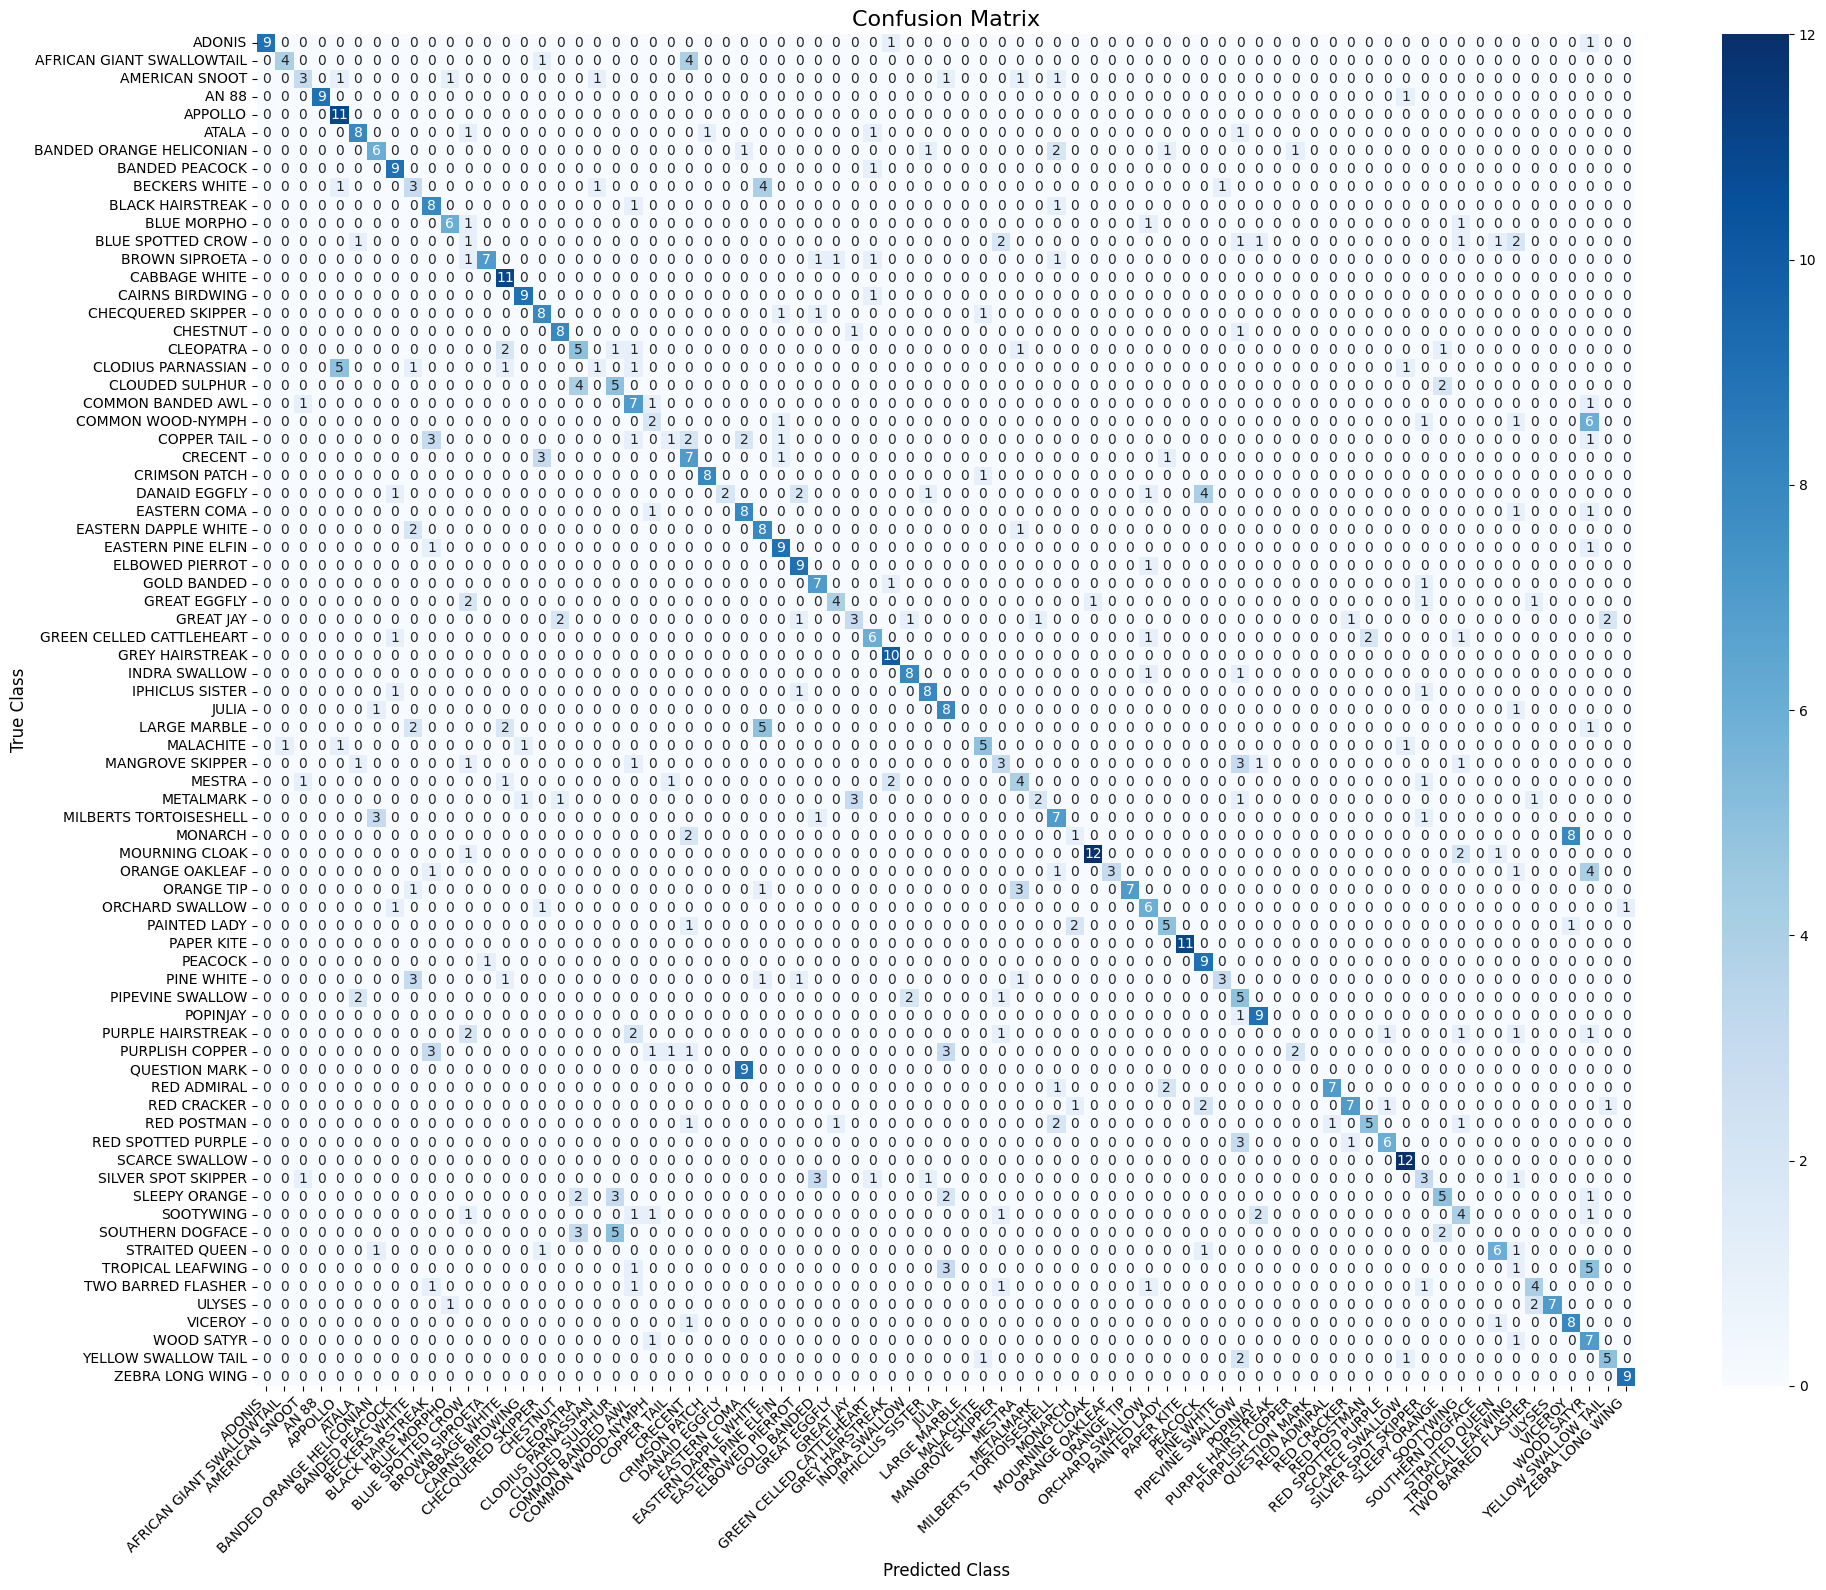

In [ ]:
# Evaluate the final model on the Test Set
labels_reais, labels_previstos = evaluate_on_test(
    vae_augmented_model,
    test_loader,
    device,
    class_names=test_dataset.classes
)

#### GAN

In [ ]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        
        # Input: vettore di rumore di dimensione latent_dim (es. 100x1x1)
        self.main = nn.Sequential(
            # Stato iniziale: Convoluzione trasposta per espandere il vettore latente
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=4, stride=1, padding=0, bias=False), # -> 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False), # -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),  # -> 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),   # -> 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1, bias=False),    # -> 64x64
            nn.Tanh() # Output normalizzato in [-1, 1]
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Input: Immagine di dimensioni 3x64x64 (vera o generata)
        self.main = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1, bias=False), # -> 32x32
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, bias=False), # -> 16x16
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False), # -> 8x8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False), # -> 4x4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False), # -> 1x1 (singolo valore)
            nn.Sigmoid() # Restituisce una probabilità: 1 = Vero, 0 = Falso
        )

    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)

### Conditional GAN (cGAN)

To overcome the stochastic nature and lack of control inherent in standard Generative Adversarial Networks (GANs), we employ a Conditional GAN (cGAN) framework as our primary generative data augmentation strategy. While a vanilla GAN generates synthetic images from arbitrary latent noise without targeting specific categories, a Conditional GAN guides the generation process by conditioning both the Generator and the Discriminator on class labels. In our architecture, the target butterfly species (spanning 75 distinct classes) is transformed via an embedding layer into a dense vector, which is subsequently concatenated with the latent noise vector. This architectural modification allows the Generator to synthesize highly specific intra-class visual features. Consequently, the cGAN enables a deterministic and balanced data augmentation pipeline, allowing us to artificially expand under-represented butterfly species and directly assist the downstream BaselineCNN classifier with explicitly labeled synthetic samples.